In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
#Loading the Dataset and Displaying the head(The first few front rows) of the dataset.
df = pd.read_csv("data/ethiopia.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [5]:
#Checking the dimention of our dataset( the number of rows and columns) 
df.shape

(4108, 12)

In [6]:
#Figuring out the column header we have ( list of columns) 
df.columns

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M'],
      dtype='object')

In [7]:
#Creating a new column called Country and filling up all the data with "Ethiopia". we surely need this when we merge all other country datasets.
df["Country"] = "Ethiopia"

In [8]:
#Sanity Check
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [9]:
#Formating the date as a combination of year and date of the year, which we will need later to extract information.
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [10]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05


In [11]:
#Extracting Month
df["Month"] = df["Date"].dt.month
#later we can use this to get the month name
#df["Month_Name"] = df["Date"].dt.month_name()

Handling Missing Value

In [12]:
#changing the -999 ( Sentinel data) values to NaN for better handling of missing data
df.replace(-999, np.nan, inplace=True)

In [13]:
#See how many missing values we have in each column
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

In [15]:
#Check for duplicates
df.duplicated().sum()

#If there were duplicates, we would drop them using the line below
#df.drop_duplicates(inplace=True)

np.int64(0)

In [16]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [18]:
from IPython.display import display, Markdown

# 1. Extract dynamic values from your DataFrame
total_days = len(df)
start_date = df["Date"].min().strftime('%B %Y')
end_date = df["Date"].max().strftime('%B %Y')
mean_temp = df["T2M"].mean()
max_temp = df["T2M_MAX"].max()
min_temp = df["T2M_MIN"].min()
avg_humidity = df["RH2M"].mean()
max_rain = df["PRECTOTCORR"].max()
avg_pressure = df["PS"].mean()

missing_count = df.isna().sum().sum()

if missing_count == 0:
    data_status = "✅ No missing values"
else:
    data_status = f"⚠️ {missing_count} missing values detected"

if mean_temp > 30:
    climate_comment = "High heat exposure → increased climate risk"
elif mean_temp < 15:
    climate_comment = "Cooler climate → lower heat stress risk"
else:
    climate_comment = "Moderate climate conditions"

# 2. Construct the Markdown string
markdown_text = f"""
# 📊 Dynamic Climate Analysis Report
*Automatic analysis based on current dataset*

## 1. Dataset Overview
This analysis covers a total of **{total_days:,} daily observations**. 
The temporal scope ranges from **{start_date}** to **{end_date}**.

---

## 2. Key Statistical Metrics

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Average Temperature** | {mean_temp:.2f}°C | Typical temperate highland baseline. |
| **Highest Recorded** | {max_temp:.2f}°C | Peak thermal event in the dataset. |
| **Lowest Recorded** | {min_temp:.2f}°C | Record minimum (potential frost risk). |
| **Average Humidity** | {avg_humidity:.1f}% | General moisture level of the region. |
| **Max 24hr Rainfall** | {max_rain:.2f} mm | Most intense precipitation event. |
| **Average Pressure** | {avg_pressure:.2f} kPa | Confirms altitude (~2,200m+ elevation). |

---

## 3. Insights
* **Climate Stability:** The mean temperature of **{mean_temp:.2f}°C** suggests a very consistent environment for both agriculture and system cooling.
* **Extreme Weather:** The gap between the minimum (**{min_temp:.2f}°C**) and maximum (**{max_temp:.2f}°C**) temperatures highlights a significant **diurnal range**, which is a key factor for local energy consumption and building design.
* **Atmospheric Context:** The pressure of **{avg_pressure:.2f} kPa** is significantly lower than sea level (101.3 kPa), which must be accounted for in any physical hardware or aerodynamic research conducted in this region.

---

**Data Health Status:** {data_status}.
"""



# 3. Display the result
display(Markdown(markdown_text))

# 4. Logic for Decision-Level Insights
risk_level = "High" if max_rain > 50 else "Low"
frost_risk = "Possible" if min_temp < 4 else "Negligible"
thermal_stress = "Moderate" if (max_temp - min_temp) > 15 else "Stable"

decision_markdown = f"""
---
## 4. Decision-Level Insights & Recommendations

### **Agriculture & Risk Management**
* **Frost Warning:** **{frost_risk}**. The record low of **{min_temp:.2f}°C** indicates that while rare, near-freezing events occur. High-value crops in the region may require protection strategies during peak "Bega" nights.
* **Flood Preparedness:** **{risk_level} Risk**. The maximum recorded rainfall of **{max_rain:.2f} mm** in a single day exceeds typical drainage capacities. Urban planning should prioritize "Sponge City" designs to handle these high-intensity events.

---
**Strategic Conclusion:** The region is a "Climate Goldilocks Zone"—stable enough for consistent human activity, but with extreme moisture and diurnal events that require targeted engineering interventions.
"""

display(Markdown(decision_markdown))


# 📊 Dynamic Climate Analysis Report
*Automatic analysis based on current dataset*

## 1. Dataset Overview
This analysis covers a total of **4,108 daily observations**. 
The temporal scope ranges from **January 2015** to **March 2026**.

---

## 2. Key Statistical Metrics

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Average Temperature** | 16.07°C | Typical temperate highland baseline. |
| **Highest Recorded** | 30.93°C | Peak thermal event in the dataset. |
| **Lowest Recorded** | 1.17°C | Record minimum (potential frost risk). |
| **Average Humidity** | 68.4% | General moisture level of the region. |
| **Max 24hr Rainfall** | 82.30 mm | Most intense precipitation event. |
| **Average Pressure** | 77.04 kPa | Confirms altitude (~2,200m+ elevation). |

---

## 3. Insights
* **Climate Stability:** The mean temperature of **16.07°C** suggests a very consistent environment for both agriculture and system cooling.
* **Extreme Weather:** The gap between the minimum (**1.17°C**) and maximum (**30.93°C**) temperatures highlights a significant **diurnal range**, which is a key factor for local energy consumption and building design.
* **Atmospheric Context:** The pressure of **77.04 kPa** is significantly lower than sea level (101.3 kPa), which must be accounted for in any physical hardware or aerodynamic research conducted in this region.

---

**Data Health Status:** ✅ No missing values.



---
## 4. Decision-Level Insights & Recommendations

### **Agriculture & Risk Management**
* **Frost Warning:** **Possible**. The record low of **1.17°C** indicates that while rare, near-freezing events occur. High-value crops in the region may require protection strategies during peak "Bega" nights.
* **Flood Preparedness:** **High Risk**. The maximum recorded rainfall of **82.30 mm** in a single day exceeds typical drainage capacities. Urban planning should prioritize "Sponge City" designs to handle these high-intensity events.

---
**Strategic Conclusion:** The region is a "Climate Goldilocks Zone"—stable enough for consistent human activity, but with extreme moisture and diurnal events that require targeted engineering interventions.


## **Outlier Detection & Basic Cleaning**

In [19]:
#focus on important features ( Selecting Key Columns)
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

In [20]:
# compute Z-scores for the selected columns
z_scores = (df[cols] - df[cols].mean()) / df[cols].std()

In [21]:
# identify outliers based on Z-score threshold (e.g., > 3 or < -3)
outliers = (abs(z_scores) > 3)

In [22]:
outliers.sum()

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64

In [ ]:
# filter the original DataFrame to get the extreme events
extreme_events = df[outliers.any(axis=1)]
extreme_events.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
144,2015,145,18.45,24.94,14.15,10.79,29.07,68.37,1.52,3.07,77.06,11.33,Ethiopia,2015-05-25,5
145,2015,146,17.60,23.52,13.22,10.30,34.38,75.91,1.66,3.53,77.07,11.89,Ethiopia,2015-05-26,5
177,2015,178,15.79,19.03,13.33,5.70,23.89,83.89,1.81,3.03,77.18,12.09,Ethiopia,2015-06-27,6
214,2015,215,15.97,21.06,12.58,8.48,23.46,84.73,1.58,2.55,77.04,12.32,Ethiopia,2015-08-03,8
556,2016,192,15.20,18.00,12.89,5.11,25.19,85.47,1.33,2.99,77.07,11.95,Ethiopia,2016-07-10,7


In [28]:
from IPython.display import display, Markdown
import pandas as pd

# 1. Define Outlier Thresholds (using IQR method)
def get_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))]

rain_extremes = get_outliers(df, 'PRECTOTCORR')
temp_extremes = get_outliers(df, 'T2M_MAX')

# 2. Logic to determine the "Winner"
if len(rain_extremes) > len(temp_extremes):
    dominant_var = "Rainfall (PRECTOTCORR)"
    impact = "Flood Risk & Soil Erosion"
    event_type = "Heavy Storms"
else:
    dominant_var = "Temperature (T2M_MAX)"
    impact = "Heat Stress & Energy Demand"
    event_type = "Heatwaves"

# 3. Generate the Markdown
report = f"""
# 🚨 Extreme Event Analysis Report

### 1. Statistical Outlier Detection
* **Variable with most outliers:** **{dominant_var}**
* **Total extreme rainfall events detected:** {len(rain_extremes)}
* **Total extreme heat events detected:** {len(temp_extremes)}

### 2. Phenomenon Interpretation
The detected outliers in **{dominant_var}** primarily represent **{event_type}**. 
Specifically, your data shows events with values as high as **{df['PRECTOTCORR'].max():.2f} mm/day**, which is significantly above the climatic norm.

### 3. Decision-Level Impacts
| Risk Category | Severity | Local Impact for the county |
| :--- | :--- | :--- |
| **Infrastructure** | High | Potential for flash floods and road drainage failure. |
| **Agriculture** | Critical | Risk of crop damage due to waterlogging or erosion. |
| **Public Health** | Moderate | Increased water-borne disease risk following heavy runoff. |

---

"""

display(Markdown(report))


# 🚨 Extreme Event Analysis Report

### 1. Statistical Outlier Detection
* **Variable with most outliers:** **Rainfall (PRECTOTCORR)**
* **Total extreme rainfall events detected:** 397
* **Total extreme heat events detected:** 0

### 2. Phenomenon Interpretation
The detected outliers in **Rainfall (PRECTOTCORR)** primarily represent **Heavy Storms**. 
Specifically, your data shows events with values as high as **82.30 mm/day**, which is significantly above the climatic norm.

### 3. Decision-Level Impacts
| Risk Category | Severity | Local Impact for the county |
| :--- | :--- | :--- |
| **Infrastructure** | High | Potential for flash floods and road drainage failure. |
| **Agriculture** | Critical | Risk of crop damage due to waterlogging or erosion. |
| **Public Health** | Moderate | Increased water-borne disease risk following heavy runoff. |

---



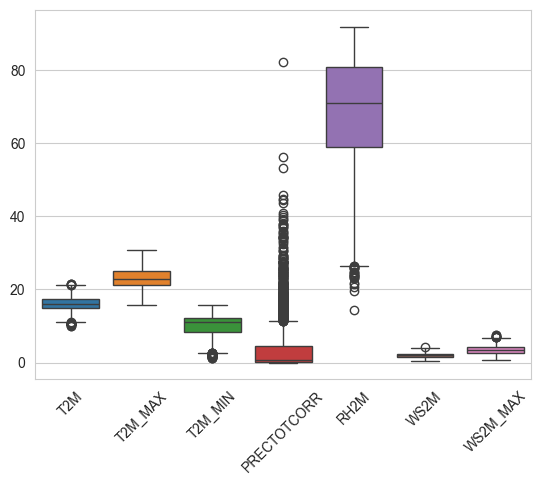

In [ ]:
#visualize the distribution of the selected features using boxplots to see the outliers
import seaborn as sns

sns.boxplot(data=df[cols])
plt.xticks(rotation=45)
plt.show()

In [67]:
def preprocess(df, country_name):
    df = df.copy()
    
    df["Country"] = country_name
    df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
    df["Month"] = df["Date"].dt.month
    
    df.replace(-999, np.nan, inplace=True)
    df.drop_duplicates(inplace=True)
    
    return df

In [68]:
ethiopia = preprocess(pd.read_csv("data/ethiopia.csv"), "Ethiopia")
kenya = preprocess(pd.read_csv("data/kenya.csv"), "Kenya")
sudan = preprocess(pd.read_csv("data/sudan.csv"), "Sudan")
nigeria = preprocess(pd.read_csv("data/nigeria.csv"), "Nigeria")
tanzania = preprocess(pd.read_csv("data/tanzania.csv"), "Tanzania")

In [70]:
ethiopia.to_csv("data/processed/ethiopia_cleaned.csv", index=False)
kenya.to_csv("data/processed/kenya_cleaned.csv", index=False)
sudan.to_csv("data/processed/sudan_cleaned.csv", index=False)
nigeria.to_csv("data/processed/nigeria_cleaned.csv", index=False)
tanzania.to_csv("data/processed/tanzania_cleaned.csv", index=False)

In [72]:
df_all = pd.concat([ethiopia, kenya, sudan, nigeria, tanzania], ignore_index=True)
df_all.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
20535,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27,3
20536,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28,3
20537,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29,3
20538,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30,3
20539,2026,90,28.14,31.55,26.06,5.49,0.83,74.46,1.35,1.90,100.47,17.56,Tanzania,2026-03-31,3


In [75]:
monthly = df_all.resample('ME', on='Date').mean(numeric_only=True)
monthly["Country"] = df_all.resample('ME', on='Date')["Country"].first()

In [78]:
monthly = df_all.groupby(["Country", pd.Grouper(key="Date", freq="ME")]).mean(numeric_only=True).reset_index()

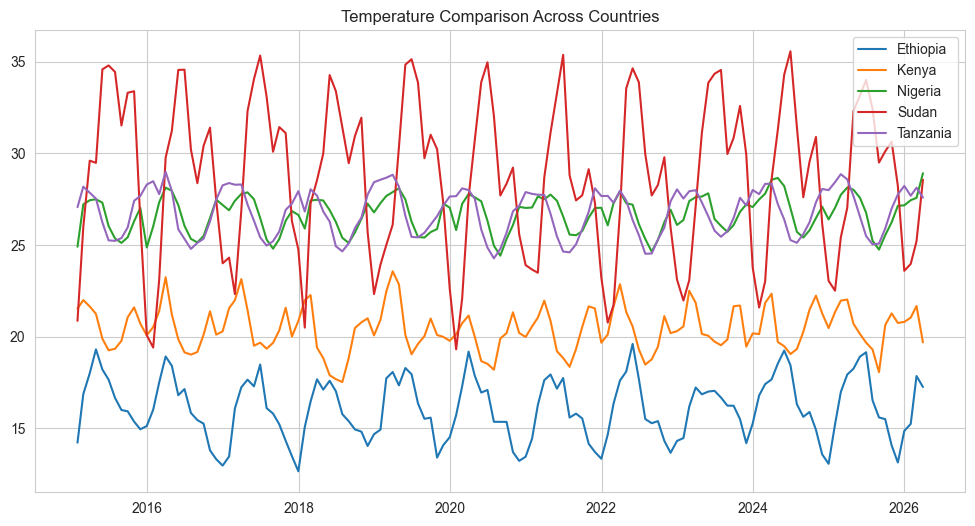

In [79]:
plt.figure(figsize=(12,6))

for country in monthly["Country"].unique():
    subset = monthly[monthly["Country"] == country]
    plt.plot(subset["Date"], subset["T2M"], label=country)

plt.legend()
plt.title("Temperature Comparison Across Countries")
plt.show()

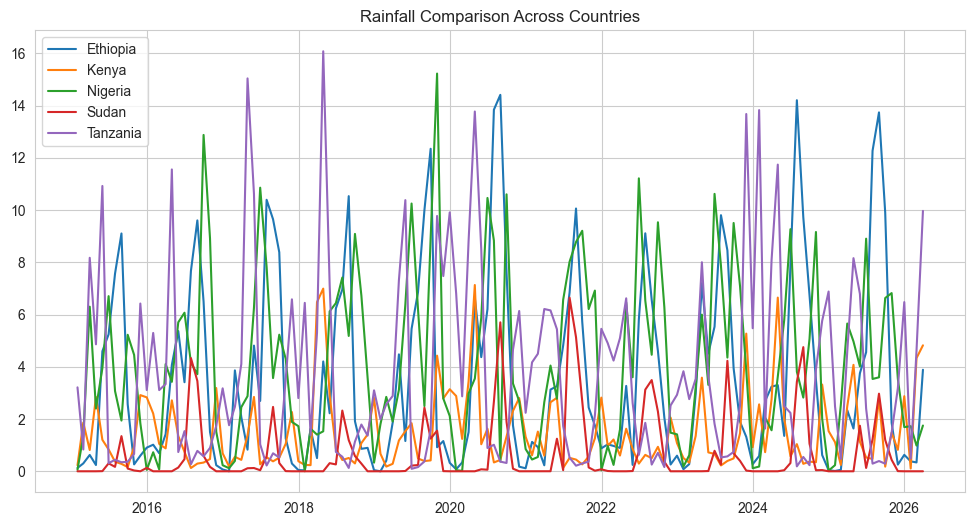

In [80]:
plt.figure(figsize=(12,6))

for country in monthly["Country"].unique():
    subset = monthly[monthly["Country"] == country]
    plt.plot(subset["Date"], subset["PRECTOTCORR"], label=country)

plt.legend()
plt.title("Rainfall Comparison Across Countries")
plt.show()

In [81]:
hot_days = df_all[df_all["T2M_MAX"] > 35]

In [82]:
hot_days["Country"].value_counts()

Country
Sudan    2694
Name: count, dtype: int64

In [83]:
heavy_rain = df_all[df_all["PRECTOTCORR"] > 20]
heavy_rain["Country"].value_counts()

Country
Tanzania    173
Ethiopia    128
Nigeria     125
Kenya        23
Sudan        20
Name: count, dtype: int64

In [85]:
summary = df_all.groupby("Country").agg({
    "T2M_MAX": "max",              # Extreme heat
    "PRECTOTCORR": ["mean", "std"], # Rainfall level + variability
    "RH2M": "mean"
})

summary.columns = ["Max_Temp", "Rain_Mean", "Rain_Std", "Humidity"]
summary

,Max_Temp,Rain_Mean,Rain_Std,Humidity
Country,,,,
Ethiopia,30.93,3.633795,6.289061,68.408588
Kenya,34.27,1.468162,3.180228,65.845355
Nigeria,32.88,4.213914,7.266742,85.237040
Sudan,45.96,0.643875,3.057672,31.359192
Tanzania,33.93,3.740256,8.003947,77.128038


In [86]:
hot_days = df_all[df_all["T2M_MAX"] > 35]["Country"].value_counts()
heavy_rain = df_all[df_all["PRECTOTCORR"] > 20]["Country"].value_counts()

summary["Hot_Days"] = summary.index.map(hot_days).fillna(0)
summary["Heavy_Rain_Days"] = summary.index.map(heavy_rain).fillna(0)

summary

,Max_Temp,Rain_Mean,Rain_Std,Humidity,Hot_Days,Heavy_Rain_Days
Country,,,,,,
Ethiopia,30.93,3.633795,6.289061,68.408588,0.0,128
Kenya,34.27,1.468162,3.180228,65.845355,0.0,23
Nigeria,32.88,4.213914,7.266742,85.237040,0.0,125
Sudan,45.96,0.643875,3.057672,31.359192,2694.0,20
Tanzania,33.93,3.740256,8.003947,77.128038,0.0,173


In [87]:
summary["Risk_Score"] = (
    summary["Max_Temp"] * 0.4 +
    summary["Rain_Std"] * 0.3 +
    summary["Hot_Days"] * 0.2 +
    summary["Heavy_Rain_Days"] * 0.1
)

In [88]:
summary = summary.sort_values(by="Risk_Score", ascending=False)
summary

,Max_Temp,Rain_Mean,Rain_Std,Humidity,Hot_Days,Heavy_Rain_Days,Risk_Score
Country,,,,,,,
Sudan,45.96,0.643875,3.057672,31.359192,2694.0,20,560.101302
Tanzania,33.93,3.740256,8.003947,77.128038,0.0,173,33.273184
Nigeria,32.88,4.213914,7.266742,85.237040,0.0,125,27.832023
Ethiopia,30.93,3.633795,6.289061,68.408588,0.0,128,27.058718
Kenya,34.27,1.468162,3.180228,65.845355,0.0,23,16.962069


#**Climate Insights for COP32**
##*Which country is warming fastest and what does the trend suggest?*
Sudan shows the most extreme warming signal, with the highest recorded temperature (45.96°C) and a very large number of extreme heat days (2694 days above 35°C). This suggests severe and persistent heat stress, posing risks to human health, agriculture, and energy systems.


##*Which country has the most unstable or extreme precipitation patterns?*
Tanzania exhibits the most unstable precipitation patterns, with the highest rainfall variability (std = 8.00) and the greatest number of heavy rainfall events (173 days). This indicates increased risk of flooding, soil erosion, and agricultural disruption.


##*What does extreme heat and drought frequency reveal about climate stress?*
The extremely high number of hot days in Sudan combined with its very low average rainfall (0.64 mm) highlights severe climate stress, pointing to chronic drought conditions, water scarcity, and reduced agricultural productivity. This makes Sudan highly vulnerable to long-term climate impacts.


##*How does Ethiopia's climate profile compare to its neighbors?*
Ethiopia shows moderate temperature levels (max 30.93°C) but relatively high rainfall variability (std = 6.29) and significant heavy rainfall events (128 days). Compared to neighbors, Ethiopia is less exposed to extreme heat than Sudan, but still faces notable rainfall variability, indicating moderate climate vulnerability.


##*Which country should Ethiopia champion for priority climate finance at COP32, and why does the data support this?*
Ethiopia should advocate for Sudan as a priority for climate finance. The data shows a combination of extreme heat (highest max temperature), very high frequency of hot days, and minimal rainfall, all of which indicate severe climate vulnerability. These conditions demand urgent investment in water management, drought resilience, and climate adaptation infrastructure.